In [23]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "2"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"

import numpy as np
import jax
import jax.numpy as jnp
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
plt.style.use("ggplot")

In [24]:
n_projections = 2048
swd_seed = 42
nx = ny = 20
flat_length = (nx + 1) * (ny + 1)  # 441

# ---------------------------------------------------------------------------
# JAX sliced Wasserstein distance (memory-efficient, supports unequal sizes)
# ---------------------------------------------------------------------------
def sliced_wasserstein_jax(x, y, n_projections=512, seed=42, chunk_size=64, p=2):
    """
    Memory-efficient SWD in JAX. Processes projections in chunks.
    Supports unequal sample sizes via quantile interpolation.
    chunk_size=64 uses ~100 MB/kernel; increase for speed, decrease for memory.
    """
    n_x, d = x.shape
    n_y = y.shape[0]
    assert n_projections % chunk_size == 0

    t_x = (jnp.arange(n_x, dtype=jnp.float32) + 0.5) / n_x
    t_y = (jnp.arange(n_y, dtype=jnp.float32) + 0.5) / n_y
    t   = jnp.sort(jnp.concatenate([t_x, t_y]))

    @jax.jit
    def chunk_cost(key):
        theta = jax.random.normal(key, (chunk_size, d))
        theta = theta / jnp.linalg.norm(theta, axis=1, keepdims=True)
        xp = jnp.sort(x @ theta.T, axis=0).T
        yp = jnp.sort(y @ theta.T, axis=0).T

        def one_cost(xi, yi):
            return jnp.mean((jnp.interp(t, t_x, xi) - jnp.interp(t, t_y, yi)) ** p)

        return jnp.mean(jax.vmap(one_cost)(xp, yp))

    keys = jax.random.split(jax.random.PRNGKey(seed), n_projections // chunk_size)
    cost = jnp.mean(jnp.array([chunk_cost(k) for k in keys]))
    return cost ** (1.0 / p)

In [25]:
ref_samps = np.load("mcmc_main/chain_000/hmala_samples_delta.npy").reshape(-1, nx + 1, ny + 1, 3)[:, :, :, 0].reshape(-1, flat_length)
ref_samps = ref_samps[::5, :]
conv_samps = np.load("mcmc_main_converge_samps/chain_000/hmala_samples_delta.npy").reshape(-1, nx + 1, ny + 1, 3)[:, :, :, 0].reshape(-1, flat_length)

us = np.load("training_dataset/parameters_delta.npy").reshape(-1, nx + 1, ny + 1, 3)[:, :, :, 0].reshape(-1, flat_length)[:120000, :]

In [26]:
base_swd = float(sliced_wasserstein_jax(
    jnp.asarray(ref_samps),
    jnp.asarray(us),
    n_projections=n_projections,
    seed=3,
))

In [27]:
base_swd

0.18262235820293427

In [28]:
rel_swd_list = []
sample_no_list = [2 ** i for i in range(1, 15)]          # 2 … 16384
sample_no_list += [20000, 30000, 40000, 50000]
sample_no_list  = sorted(set(sample_no_list))

for j, sample_no in enumerate(tqdm(sample_no_list)):
    conv_sub = conv_samps[:sample_no, :]

    rel_swd_list.append(float(sliced_wasserstein_jax(
        jnp.asarray(ref_samps),
        jnp.asarray(conv_sub),
        n_projections=n_projections,
        seed=swd_seed,
    )))

  0%|          | 0/18 [00:00<?, ?it/s]

In [29]:
rel_swd = [swd / base_swd for swd in rel_swd_list]

In [ ]:
np.save("test_swd.npy", np.array(rel_swd))

: 

In [30]:
input_dir = "convergence_results_final"
mcmc_main_swd = np.load(os.path.join(input_dir, "rel_swd_obs.npy"))

mcmc_main_avg = np.mean(mcmc_main_swd, axis=0)

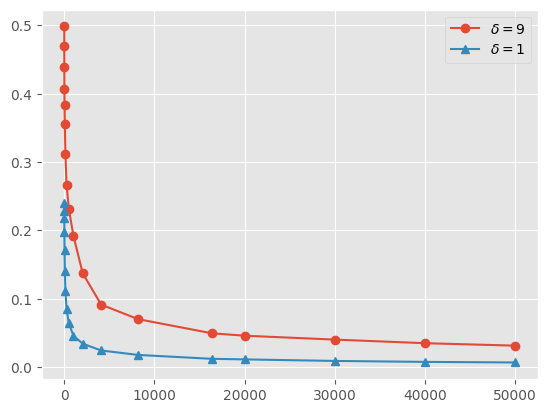

In [32]:
plt.plot(sample_no_list, rel_swd, marker="o", label=r"$\delta = 9$")
plt.plot(sample_no_list, mcmc_main_avg, marker="^", label=r"$\delta = 1$")
# plt.xscale("log")
# plt.yscale("log")
plt.legend()

In [33]:
rel_swd

[0.49836409197802894,
 0.4704246939291893,
 0.4389879498961249,
 0.40710891749790035,
 0.38373650073978555,
 0.3561384982300714,
 0.31118945910266665,
 0.2669487096448075,
 0.23099112657182497,
 0.19168349777680843,
 0.13707966184217,
 0.09125720416799565,
 0.07002739833834044,
 0.049316442944066535,
 0.04580547051265387,
 0.04010483715212476,
 0.034851890208532785,
 0.03126468463872657]

In [12]:
def get_pca_fns(us, explained_var_threshold=0.99):
    """
    Whitened PCA. Returns encode/decode callables and a residual variance sampler.
    """
    n = us.shape[0]
    mean_us = us.mean(axis=0)
    X = us - mean_us

    _, S, Vt = np.linalg.svd(X / np.sqrt(n - 1), full_matrices=False)
    V = Vt.T

    expl_var = (S ** 2) / (S ** 2).sum()
    k = int(np.searchsorted(np.cumsum(expl_var), explained_var_threshold) + 1)

    V_kept, S_kept = V[:, :k], S[:k]
    V_res,  S_res  = V[:, k:], S[k:]

    def pca_encode(b):
        return (b - mean_us) @ V_kept / S_kept

    def pca_decode(z):
        return mean_us + (z * S_kept) @ V_kept.T

    def sample_extra(n_samp=1):
        """Per-sample residual noise from the unexplained variance component."""
        eps = np.random.randn(n_samp, S_res.shape[0])
        return (eps * S_res) @ V_res.T  # (n_samp, flat_length)

    def extra_cov():
        return V_res @ np.diag(S_res ** 2) @ V_res.T

    return pca_encode, pca_decode, k, sample_extra, extra_cov

In [21]:
_, _, k, _, _ = get_pca_fns(ref_samps, explained_var_threshold=0.70)

In [22]:
k

66